# Tutorial 03 · Readout Cloud Tests

This notebook combines the circular-cloud tests in one place.

The goal is to answer one practical question:

> **How can we make IQ clouds look circular, and what does each method actually mean?**

We compare three approaches:

1. **Statistical IQ-SNR scaling**: use the measured IQ cloud separation and width.
2. **Conductance-contrast scaling**: use `RLC_sensor.calculate_meaningful_snr()` as a heuristic.
3. **JAX white-noise scaling**: use the existing JAX backend `snr` parameter.

The most important idea is simple: circular clouds come from independent white noise added equally to I and Q.

## 1. Imports

We use the NumPy/full-RLC backend for the first two tests, and the JAX backend for the third test.

In [34]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# JAX is only needed for the final comparison test.
import jax
import jax.numpy as jnp

repo_root = Path.cwd().parent if Path.cwd().name == 'tutorials' else Path.cwd()
sys.path.append(str(repo_root / 'src'))

from readout_simulator import (
    JAXReadoutSimulator,
    OU_noise,
    QuantumDotSystem,
    RLC_sensor,
    generate_sensor_iq_dataset,
    integrate_iq_traces,
    sample_integrated_iq,
)
from readout_simulator.noise_models import SpectrumNoise

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 125,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
})

## 2. Small Readout Problem

This is the same two-state readout idea as tutorial 03, but with fewer points so the notebook runs quickly.

In [35]:
# Two dots, one sensor.
dot_system = QuantumDotSystem(
    Cdd=np.array([[1.0, -0.22], [-0.22, 1.0]]),
    Cds=np.array([[0.4], [0.2]]),
)

# One RLC charge sensor with a Coulomb peak.
sensor = RLC_sensor(
    {'Lc': 800e-9, 'Cp': 0.5e-12, 'RL': 40, 'Rc': 0.0, 'Z0': 50},
    {'g0': 1/50, 'eps0': 0.45, 'eps_width': 1.0},
)

# Keep this small: the NumPy backend solves the full RLC ODE repeatedly.
dt = 2e-9
times = np.arange(0.0, 500e-9, dt)
times_ns = 1e9 * times

# Two charge states = two classes in the IQ clouds.
charge_states_np = np.array([[1, 0], [0, 1]])
charge_state_labels = ['[1, 0]', '[0, 1]']
state_colours = ['#2563EB', '#F97316']

# Number of clouds points per state.
n_realisations = 100

# We sample integrated IQ points at these times.
integration_times_ns = np.array([50, 250, 800])
integration_indices = np.clip(
    np.rint(integration_times_ns * 1e-9 / dt).astype(int) - 1,
    0,
    len(times) - 1,
)

# Fixed random seed: re-running gives the same clouds.
rng = np.random.default_rng(42)

[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 0.000e+00 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: None
  Energy noise model: None


## 3. Helper Functions

These helpers are intentionally short. They do two things:

- calculate a statistical IQ SNR;
- add equal independent white noise to I and Q, then re-integrate.

In [36]:
def projected_iq_statistics(i_values, q_values):
    """Return centre separation, projected cloud width, and SNR."""
    # Centre of each cloud: [mean I, mean Q].
    centres = np.column_stack((i_values.mean(1), q_values.mean(1)))

    # Axis from state 0 to state 1.
    separation_vector = centres[1] - centres[0]
    separation = np.linalg.norm(separation_vector)
    readout_axis = separation_vector / separation

    # Project 2D IQ points onto the state-separation axis.
    projected = [
        np.column_stack((i_values[state], q_values[state])) @ readout_axis
        for state in range(2)
    ]

    # Average the two projected variances.
    pooled_std = np.sqrt(np.mean([
        np.var(values, ddof=1) for values in projected
    ]))
    return separation, pooled_std, separation / pooled_std


def add_white_iq_noise(I_raw, Q_raw, white_sample_std, seed=42):
    """Add equal independent sample noise to I and Q, then re-integrate."""
    local_rng = np.random.default_rng(seed)
    I_noisy = I_raw + local_rng.normal(0.0, white_sample_std, I_raw.shape)
    Q_noisy = Q_raw + local_rng.normal(0.0, white_sample_std, Q_raw.shape)
    I_int, Q_int = integrate_iq_traces(I_noisy, Q_noisy, axis=-1)
    I_pts, Q_pts = sample_integrated_iq(I_int, Q_int, integration_indices, axis=-1)
    return I_noisy, Q_noisy, I_int, Q_int, I_pts, Q_pts


def squeeze_sensor_axis(points):
    """Convert (state, realisation, sensor, time) to (state, realisation, time)."""
    return points[:, :, 0, :] if points.ndim == 4 else points

## 4. Generate One Intrinsic Full-RLC Dataset

This is the physical tutorial-03-style signal: shared coloured detuning noise goes through the conductance peak and full RLC simulation.

We reuse this same intrinsic dataset for the first two cloud tests.

In [37]:
def psd_1f(freq):
    """Safe 1/f shape: zero at DC, 1/f elsewhere."""
    spectrum = np.zeros_like(freq, dtype=float)
    np.divide(1.0, freq, out=spectrum, where=freq > 0)
    return spectrum


charge_noise_model = SpectrumNoise(psd_func=psd_1f, sigma=0.12)

intrinsic = generate_sensor_iq_dataset(
    dot_system=dot_system,
    sensors=[sensor],
    charge_states=charge_states_np,
    times=times,
    simulation_params={'eps0': 0.0},
    noise_model=charge_noise_model,
    n_realisations=n_realisations,
    integration_indices=integration_indices,
    use_stationary_initial_state=True,
)

I_intrinsic = intrinsic['I_raw']
Q_intrinsic = intrinsic['Q_raw']
I_intrinsic_points = intrinsic['I_points']
Q_intrinsic_points = intrinsic['Q_points']

print('Intrinsic raw traces:', I_intrinsic.shape)
print('Intrinsic IQ points :', I_intrinsic_points.shape)

Intrinsic raw traces: (2, 100, 1, 250)
Intrinsic IQ points : (2, 100, 1, 3)


## 5. Baseline — Tutorial 03 Without Circular-Cloud Extras

This is the original tutorial-03 idea:

1. generate one shared $1/f$ detuning-noise trajectory per realisation;
2. pass that detuning noise through the conductance peak and full RLC simulation;
3. integrate I and Q;
4. plot the sampled integrated IQ points.

No independent white I/Q measurement noise is added here. Because one scalar detuning-noise source drives both quadratures through the sensor response, the clouds can look elongated or curved instead of circular.

In [38]:
# These are the baseline tutorial-03 clouds: charge noise only, no circular broadening.
I_points_baseline = I_intrinsic_points
Q_points_baseline = Q_intrinsic_points

for col, time_ns in enumerate(integration_times_ns):
    _, _, snr_value = projected_iq_statistics(
        I_points_baseline[:, :, 0, col],
        Q_points_baseline[:, :, 0, col],
    )
    print(f'Baseline SNR at {time_ns:3d} ns: {snr_value:.2f}')

Baseline SNR at  50 ns: 2.02
Baseline SNR at 250 ns: 3.37
Baseline SNR at 800 ns: 8.27


## 6. Test A — Statistical IQ-SNR Scaling

This is the most direct statistical method.

We choose a desired SNR at a reference integration time:

$$\mathrm{SNR}(t)=\frac{\|\mu_1(t)-\mu_0(t)\|}{\sigma_{\parallel,\mathrm{pooled}}(t)}.$$

Here $\mu_0(t)$ and $\mu_1(t)$ are the centres of the two integrated IQ clouds. The numerator is therefore the distance between the state centres in the IQ plane.

The denominator is the cloud width measured along the line connecting those centres. Width perpendicular to that line matters less for distinguishing the states, so we project the cloud points onto the readout axis before computing the variance.

In plain words: this SNR says how many cloud-widths fit between the two state centres.

Then we add the amount of white I/Q noise needed to reach that target.

In [39]:
target_snr = 3.0
reference_time_ns = 400
reference_col = int(np.argmin(np.abs(integration_times_ns - reference_time_ns)))

# Measure intrinsic separation and spread at the reference time.
separation, intrinsic_std, intrinsic_snr = projected_iq_statistics(
    I_intrinsic_points[:, :, 0, reference_col],
    Q_intrinsic_points[:, :, 0, reference_col],
)

# Desired total integrated cloud width.
target_total_std = separation / target_snr

# Since independent variances add, solve for the added white-noise width.
white_integrated_std = np.sqrt(max(
    target_total_std**2 - intrinsic_std**2,
    0.0,
))

# Convert integrated white-noise width back to per-sample width.
n_reference_samples = integration_indices[reference_col] + 1
white_sample_std_stat = white_integrated_std * np.sqrt(n_reference_samples)

_, _, I_int_stat, Q_int_stat, I_points_stat, Q_points_stat = add_white_iq_noise(
    I_intrinsic,
    Q_intrinsic,
    white_sample_std_stat,
    seed=10,
)

print(f'Intrinsic SNR at {reference_time_ns} ns: {intrinsic_snr:.2f}')
print(f'Target SNR                         : {target_snr:.2f}')
print(f'White sample std                   : {white_sample_std_stat:.3e} V')

Intrinsic SNR at 400 ns: 3.37
Target SNR                         : 3.00
White sample std                   : 1.262e-03 V


## 7. Test B — Conductance-Contrast Scaling

The repository function `calculate_meaningful_snr()` gives a static conductance contrast:

$$C_G=\frac{|G_1-G_0|}{(G_1+G_0)/2}.$$

This is not a statistical IQ SNR. It has no voltage unit. So we still need one voltage scale, `measurement_noise_scale_V`.

In [40]:
# Dimensionless static conductance contrast.
conductance_contrast = sensor.calculate_meaningful_snr(
    dot_system=dot_system,
    charge_states=charge_states_np,
    sensor_index=0,
)

# Heuristic conversion from dimensionless contrast to voltage noise.
# Larger contrast -> smaller assigned noise width.
measurement_noise_scale_V = 2.0e-3
white_sample_std_contrast = measurement_noise_scale_V / conductance_contrast

_, _, I_int_contrast, Q_int_contrast, I_points_contrast, Q_points_contrast = add_white_iq_noise(
    I_intrinsic,
    Q_intrinsic,
    white_sample_std_contrast,
    seed=20,
)

print(f'Conductance contrast C_G: {conductance_contrast:.3f}')
print(f'White sample std        : {white_sample_std_contrast:.3e} V')

Conductance contrast C_G: 0.592
White sample std        : 3.379e-03 V


## 8. Test C — JAX White-Noise Scaling

The JAX backend already has a white I/Q noise path controlled by `snr`.

Here we set the detuning-noise amplitude to zero so the plot isolates circular measurement noise.

In [41]:
# JAX version of the two states and time axis.
charge_states_jax = jnp.asarray(charge_states_np, dtype=float)
times_jax = jnp.asarray(times)

# Zero detuning noise: this satisfies the JAX simulator API but isolates white I/Q noise.
zero_detuning_noise = OU_noise(sigma=0.0, gamma=1e6)

jax_simulator = JAXReadoutSimulator(dot_system=dot_system, sensors=[sensor])
jax_simulator.precompute_noise(
    key=jax.random.PRNGKey(0),
    times=times_jax,
    n_realizations=n_realisations,
    noise_model=zero_detuning_noise,
)
jax_simulator.run_simulation(
    charge_states=charge_states_jax,
    times=times_jax,
    params={'eps0': 0.0, 'snr': target_snr, 't_end': float(times[-1])},
    key=jax.random.PRNGKey(1),
)

I_jax_integrated, Q_jax_integrated = jax_simulator.get_integrated_IQ(sensor_idx=0)
I_points_jax = np.asarray(I_jax_integrated[:, :, integration_indices])
Q_points_jax = np.asarray(Q_jax_integrated[:, :, integration_indices])

print('JAX IQ points:', I_points_jax.shape)

Precomputing 100 noise trajectory segments...
Noise trajectory segments precomputed successfully.
Running simulation for 2 charge states with 100 realizations...
Processing sensor 0...
Sensor 0: Average separation = 0.000097
Simulation completed successfully.
JAX IQ points: (2, 100, 3)


## 9. Compare the Clouds

Each row is one method. Each column is one integration time. The first row is the baseline tutorial-03 workflow before adding circular white I/Q noise.

All panels are locally centred and use equal I/Q scale, so circularity is not a plotting trick.

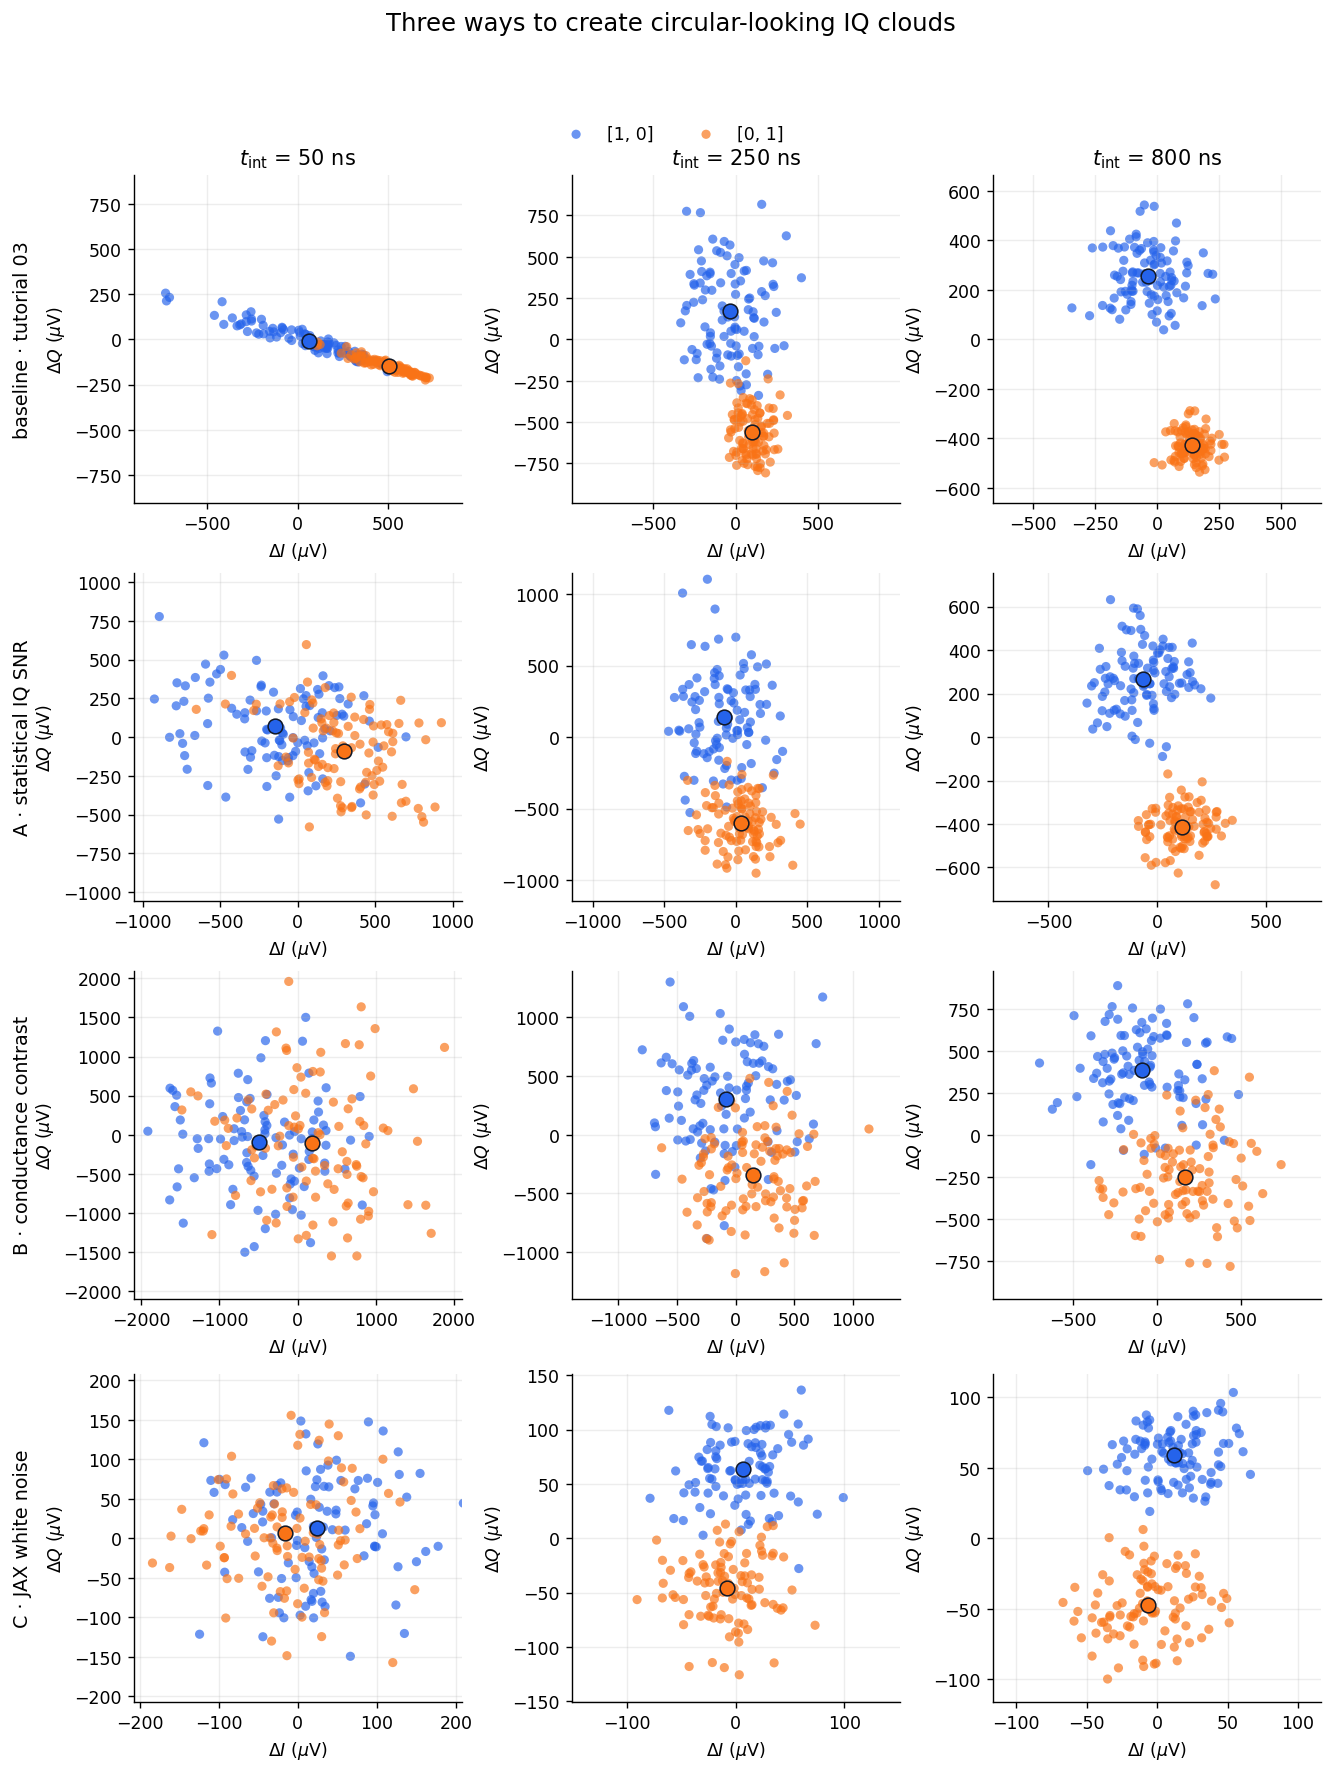

In [42]:
cloud_sets = [
    ('baseline · tutorial 03', squeeze_sensor_axis(I_points_baseline), squeeze_sensor_axis(Q_points_baseline)),
    ('A · statistical IQ SNR', squeeze_sensor_axis(I_points_stat), squeeze_sensor_axis(Q_points_stat)),
    ('B · conductance contrast', squeeze_sensor_axis(I_points_contrast), squeeze_sensor_axis(Q_points_contrast)),
    ('C · JAX white noise', I_points_jax, Q_points_jax),
]

fig, axes = plt.subplots(
    len(cloud_sets),
    len(integration_times_ns),
    figsize=(3.5 * len(integration_times_ns), 3.25 * len(cloud_sets)),
    constrained_layout=True,
)

for row, (row_label, I_pts, Q_pts) in enumerate(cloud_sets):
    for col, time_ns in enumerate(integration_times_ns):
        ax = axes[row, col]

        # Local centre and equal span for this panel.
        panel_i = I_pts[:, :, col].reshape(-1)
        panel_q = Q_pts[:, :, col].reshape(-1)
        i_lo, i_hi = np.quantile(panel_i, [0.01, 0.99])
        q_lo, q_hi = np.quantile(panel_q, [0.01, 0.99])
        i_center = 0.5 * (i_lo + i_hi)
        q_center = 0.5 * (q_lo + q_hi)
        half_span = 0.64 * max(i_hi - i_lo, q_hi - q_lo, 1e-9)

        for state_idx, label in enumerate(charge_state_labels):
            x = 1e6 * (I_pts[state_idx, :, col] - i_center)
            y = 1e6 * (Q_pts[state_idx, :, col] - q_center)
            ax.scatter(
                x, y,
                s=28,
                alpha=0.68,
                color=state_colours[state_idx],
                edgecolor='none',
                label=label if (row == 0 and col == 0) else None,
            )
            ax.scatter(
                x.mean(), y.mean(),
                s=72,
                color=state_colours[state_idx],
                edgecolor='#111827',
                linewidth=0.9,
                zorder=4,
            )

        display_span = 1e6 * half_span
        ax.set_xlim(-display_span, display_span)
        ax.set_ylim(-display_span, display_span)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel(r'$\Delta I$ ($\mu$V)')
        ax.set_ylabel(r'$\Delta Q$ ($\mu$V)')
        if row == 0:
            ax.set_title(f'$t_\\mathrm{{int}}$ = {time_ns} ns')
        if col == 0:
            ax.text(
                -0.34, 0.5, row_label,
                transform=ax.transAxes,
                rotation=90,
                va='center',
                ha='center',
                fontsize=11,
            )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)
fig.suptitle('Three ways to create circular-looking IQ clouds', y=1.08, fontsize=14)
plt.show()

## 10. Integrated I and Q Traces for Each Method

The cloud plots show sampled points at a few integration times. The plots below show the full running-average integrated traces versus time.

For each method, the left panel is integrated I and the right panel is integrated Q. Solid lines show the mean over the dataset realisations; the shaded band shows one standard deviation.

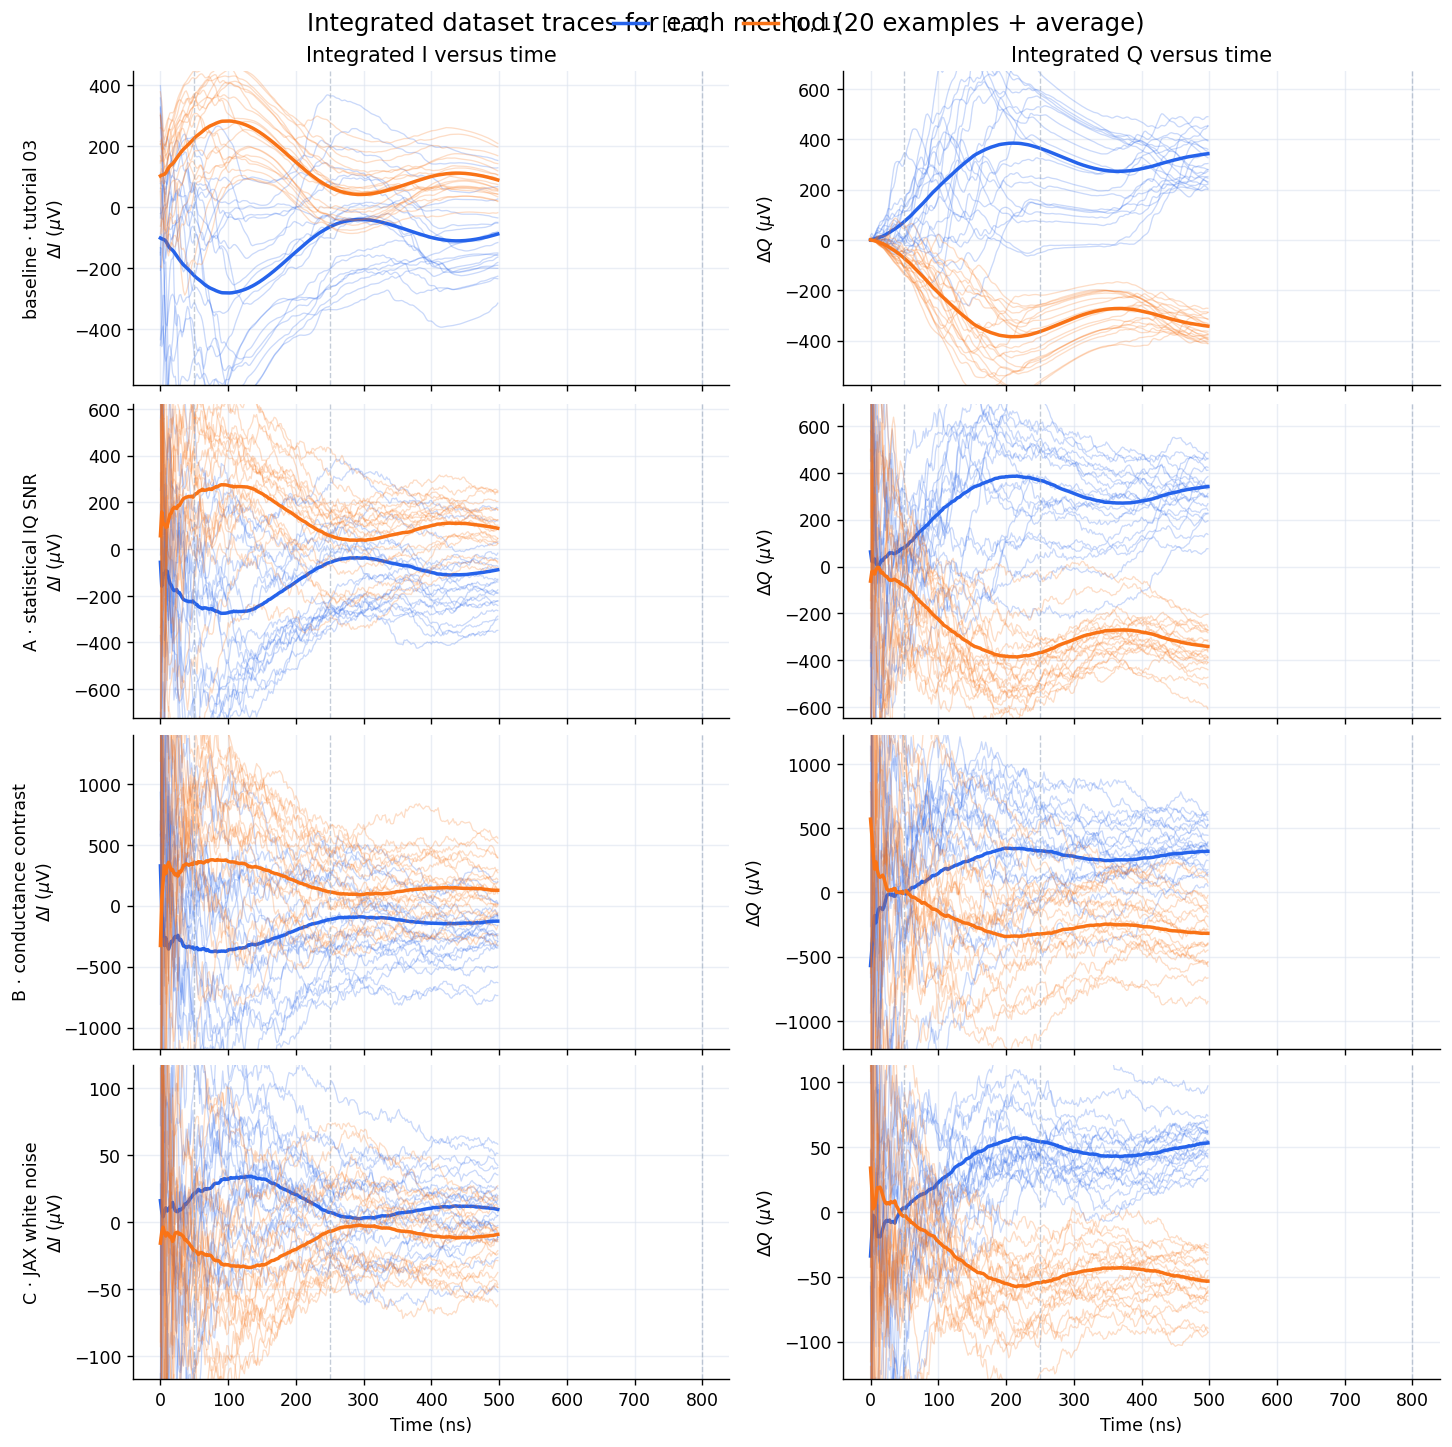

In [43]:
trace_sets = [
    ('baseline · tutorial 03', intrinsic['I_integrated'], intrinsic['Q_integrated']),
    ('A · statistical IQ SNR', I_int_stat, Q_int_stat),
    ('B · conductance contrast', I_int_contrast, Q_int_contrast),
    ('C · JAX white noise', np.asarray(I_jax_integrated), np.asarray(Q_jax_integrated)),
]

# Number of individual dataset realisations to draw per state.
# The thick line is always the average over all realisations.
n_example_traces = 20

fig, axes = plt.subplots(
    len(trace_sets),
    2,
    figsize=(11.5, 2.8 * len(trace_sets)),
    constrained_layout=True,
    sharex=True,
)

for row, (method_label, I_trace, Q_trace) in enumerate(trace_sets):
    row_I_values = []
    row_Q_values = []

    # NumPy traces have shape (state, realisation, sensor, time).
    # JAX traces have shape (state, realisation, time).
    if I_trace.ndim == 4:
        I_plot = I_trace[:, :, 0, :]
        Q_plot = Q_trace[:, :, 0, :]
    else:
        I_plot = I_trace
        Q_plot = Q_trace

    # Remove the common two-state mean so state-scale structure is visible.
    I_mid = I_plot.mean(axis=(0, 1))
    Q_mid = Q_plot.mean(axis=(0, 1))

    for state_idx, label in enumerate(charge_state_labels):
        colour = state_colours[state_idx]
        I_delta = 1e6 * (I_plot[state_idx] - I_mid)
        Q_delta = 1e6 * (Q_plot[state_idx] - Q_mid)

        n_to_plot = min(n_example_traces, I_delta.shape[0])
        I_mean = I_delta.mean(axis=0)
        Q_mean = Q_delta.mean(axis=0)

        # Thin lines: individual integrated traces from the dataset.
        for trace_idx in range(n_to_plot):
            axes[row, 0].plot(
                times_ns,
                I_delta[trace_idx],
                color=colour,
                lw=0.75,
                alpha=0.24,
            )
            axes[row, 1].plot(
                times_ns,
                Q_delta[trace_idx],
                color=colour,
                lw=0.75,
                alpha=0.24,
            )

        # Thick line: average over all realisations.
        axes[row, 0].plot(times_ns, I_mean, color=colour, lw=2.0, label=label)
        axes[row, 1].plot(times_ns, Q_mean, color=colour, lw=2.0, label=label)

        # Store plotted traces plus average for robust y-axis limits.
        row_I_values.extend([I_delta[idx] for idx in range(n_to_plot)] + [I_mean])
        row_Q_values.extend([Q_delta[idx] for idx in range(n_to_plot)] + [Q_mean])

    # Zoom y-axis per subplot using robust percentiles.
    # This keeps the typical traces visible without letting rare outliers dominate.
    for ax, values in zip(axes[row], [row_I_values, row_Q_values]):
        y_low, y_high = np.quantile(np.concatenate(values), [0.03, 0.97])
        y_center = 0.5 * (y_low + y_high)
        y_half_span = 0.58 * max(y_high - y_low, 1e-9)
        ax.set_ylim(y_center - y_half_span, y_center + y_half_span)

        for time_ns in integration_times_ns:
            ax.axvline(time_ns, color='#94A3B8', lw=0.8, ls='--', alpha=0.55)
        ax.grid(True, color='#dbe3ef', alpha=0.58, linewidth=0.8)

    axes[row, 0].set_ylabel(method_label + '\n' + r'$\Delta I$ ($\mu$V)')
    axes[row, 1].set_ylabel(r'$\Delta Q$ ($\mu$V)')

axes[0, 0].set_title('Integrated I versus time')
axes[0, 1].set_title('Integrated Q versus time')
axes[-1, 0].set_xlabel('Time (ns)')
axes[-1, 1].set_xlabel('Time (ns)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle(
    f'Integrated dataset traces for each method ({n_example_traces} examples + average)',
    y=1.02,
    fontsize=14,
)
plt.show()

## 11. What To Take Away

- **Baseline tutorial 03** uses shared detuning noise only, so the clouds need not be circular.
- **Circular shape** comes from independent, equal-variance I/Q noise.
- **Statistical IQ-SNR scaling** is the most direct way to control readout cloud overlap.
- **Conductance contrast** is useful for sensor tuning, but it needs an extra voltage scale before it can set cloud radius.
- **JAX white noise** is fast and clean, but it uses the simplified JAX signal path rather than the full NumPy/RLC ODE path.
- If the cloud still looks elongated, charge noise or sensor-response nonlinearity is still contributing appreciably.